# 📈 Task 1 — Notebook 3: Evaluation Classifier & Models Comparison

**Purpose:** Load trained model(s), run test set evaluation, generate all required plots,
and compare models side-by-side.

**Author:** [Your Name] | **GitHub:** [Your Repo URL]

---
### Notebooks in this project:
| Notebook | Purpose |
|----------|---------|
| `01_data_analysis.ipynb` | EDA |
| `02_train.ipynb` | Training |
| `03_evaluate.ipynb` | ← **You are here** — Evaluation & comparison |

## 0. Setup

In [ ]:
# ── Install dependencies ───────────────────────────────────────────────────
!pip install medmnist scikit-learn seaborn matplotlib torchvision --quiet

# ── Clone repo & add to path ───────────────────────────────────────────────
import os
REPO_URL  = 'https://github.com/Irshadcsit/ProjectX.git'   # ← updated
REPO_NAME = 'ProjectX'                                     # ← updated

if not os.path.exists(REPO_NAME):
    !git clone {REPO_URL}

os.chdir(REPO_NAME)
import sys; sys.path.insert(0, '.')
print('Repo ready. CWD:', os.getcwd())


In [19]:
import json, os
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve,
    classification_report
)

from data.dataset    import get_dataloaders, CLASS_NAMES
from models.registry import get_model, get_model_name

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

_, _, test_loader = get_dataloaders(batch_size=64, num_workers=2)

os.makedirs('outputs', exist_ok=True)
print(f'CLASS_NAMES: {CLASS_NAMES}')

Device: cuda
[Dataset] train=4708 | val=524 | test=624
[Dataset] classes=['normal', 'pneumonia'] | image_size=28×28
CLASS_NAMES: ['normal', 'pneumonia']


## 1. Select Model to Evaluate

**🔧 Change `MODEL_NAME` to evaluate a specific model.**
Run this section multiple times with different model names to build the comparison table.

Available: `'vit'| 'efficientnet'` | `'resnet'` | `'custom_cnn'`

In [20]:
# ══════════════════════════════════════════════
MODEL_NAME = 'resnet'   # ← CHANGE HERE
# ══════════════════════════════════════════════

OUTPUT_DIR  = f'outputs/{MODEL_NAME}'
MODEL_PATH  = f'{OUTPUT_DIR}/best_model.pth'

assert os.path.exists(MODEL_PATH), (
    f'Model not found at {MODEL_PATH}.\n'
    f'Train it first in 02_train.ipynb with MODEL_NAME = "{MODEL_NAME}"')

# Load model
ckpt  = torch.load(MODEL_PATH, map_location=device)
model = get_model(MODEL_NAME, pretrained=False, dropout=0.0).to(device)
model.load_state_dict(ckpt['model_state_dict'])
model_name = get_model_name(model)

print(f'Loaded: {model_name}')
print(f'  Checkpoint epoch: {ckpt["epoch"]}')
print(f'  Best val_acc:     {ckpt["val_acc"]:.4f}')

Loaded: ResNet-18
  Checkpoint epoch: 39
  Best val_acc:     0.9866


## 2. Run Inference

In [21]:
def denorm(t, mean=0.5, std=0.5):
    return (t * std + mean).clamp(0, 1)

model.eval()
all_probs, all_preds, all_labels, all_images = [], [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        logits = model(images.to(device))
        probs  = torch.sigmoid(logits).squeeze(1).cpu().numpy()
        preds  = (probs >= 0.5).astype(int)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.squeeze(1).numpy().astype(int).tolist())
        all_images.extend(images.cpu().unbind(0))

all_probs  = np.array(all_probs)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

print(f'Inference complete on {len(all_labels)} test images')

Inference complete on 624 test images


## 3. Metrics

In [22]:
fpr, tpr, _ = roc_curve(all_labels, all_probs)

metrics = {
    'model':      MODEL_NAME,
    'model_name': model_name,
    'accuracy':   float(accuracy_score(all_labels, all_preds)),
    'precision':  float(precision_score(all_labels, all_preds, zero_division=0)),
    'recall':     float(recall_score(all_labels, all_preds, zero_division=0)),
    'f1':         float(f1_score(all_labels, all_preds, zero_division=0)),
    'auc':        float(roc_auc_score(all_labels, all_probs)),
    'fpr':        fpr.tolist(),   
    'tpr':        tpr.tolist(),   
    
}

print(f'\n{"="*46}')
print(f'  TEST RESULTS — {model_name}')
print(f'{"="*46}')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f'  {k.capitalize():12s}: {v:.4f}')
print(f'{"="*46}')

print('\nFull classification report:')
print(classification_report(all_labels, all_preds,
      target_names=CLASS_NAMES, digits=4))

with open(f'{OUTPUT_DIR}/test_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'✓ Metrics saved to {OUTPUT_DIR}/test_metrics.json')


  TEST RESULTS — ResNet-18
  Accuracy    : 0.8942
  Precision   : 0.8568
  Recall      : 0.9974
  F1          : 0.9218
  Auc         : 0.9756

Full classification report:
              precision    recall  f1-score   support

      normal     0.9941    0.7222    0.8366       234
   pneumonia     0.8568    0.9974    0.9218       390

    accuracy                         0.8942       624
   macro avg     0.9255    0.8598    0.8792       624
weighted avg     0.9083    0.8942    0.8899       624

✓ Metrics saved to outputs/resnet/test_metrics.json


## 4. Visualizations

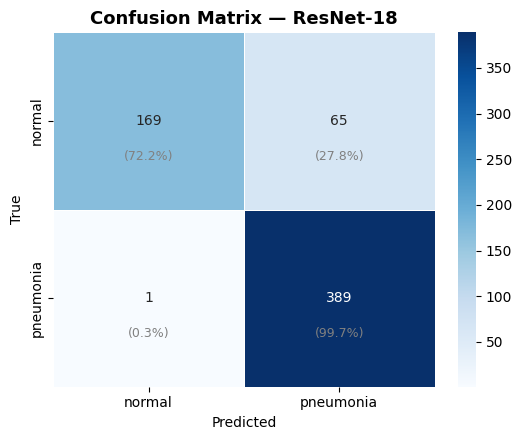

TN=169  FP=65  FN=1  TP=389
Sensitivity (Recall) = 0.9974
Specificity          = 0.7222


In [23]:
# ── Confusion Matrix ────────────────────────────────────────────────────────
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, linewidths=0.5, ax=ax)
for i in range(2):
    for j in range(2):
        ax.text(j+0.5, i+0.72, f'({cm_norm[i,j]*100:.1f}%)',
                ha='center', fontsize=9, color='gray')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'Confusion Matrix — {model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print(f'Sensitivity (Recall) = {tp/(tp+fn):.4f}')
print(f'Specificity          = {tn/(tn+fp):.4f}')

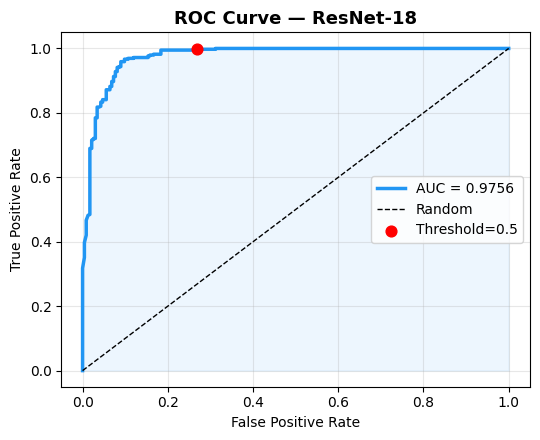

In [24]:
# ── ROC Curve ───────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr, tpr, color='#2196F3', lw=2.5, label=f'AUC = {metrics["auc"]:.4f}')
ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2196F3')
ax.scatter([fpr[np.argmin(np.abs(thresholds - 0.5))]],
           [tpr[np.argmin(np.abs(thresholds - 0.5))]],
           color='red', zorder=5, s=60, label='Threshold=0.5')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title(f'ROC Curve — {model_name}', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

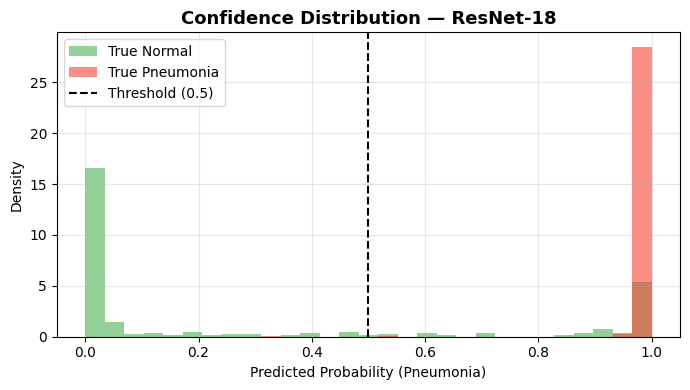

In [25]:
# ── Confidence Distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
bins = np.linspace(0, 1, 30)
ax.hist(all_probs[all_labels==0], bins=bins, alpha=0.6, color='#4CAF50',
        label='True Normal', density=True)
ax.hist(all_probs[all_labels==1], bins=bins, alpha=0.6, color='#F44336',
        label='True Pneumonia', density=True)
ax.axvline(0.5, color='black', linestyle='--', lw=1.5, label='Threshold (0.5)')
ax.set_xlabel('Predicted Probability (Pneumonia)')
ax.set_ylabel('Density')
ax.set_title(f'Confidence Distribution — {model_name}', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/confidence_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Failure Case Analysis

**Clinical interpretation:**
- 🔴 **False Negatives** (Pneumonia→Normal): Most dangerous — missed diagnosis, delayed treatment
- 🟠 **False Positives** (Normal→Pneumonia): Less dangerous — unnecessary workup but patient not harmed

False Positives (Normal → Pneumonia):   65  (over-diagnosis)
False Negatives (Pneumonia → Normal):    1  ← clinically dangerous
Total errors: 66 / 624 (10.6%)


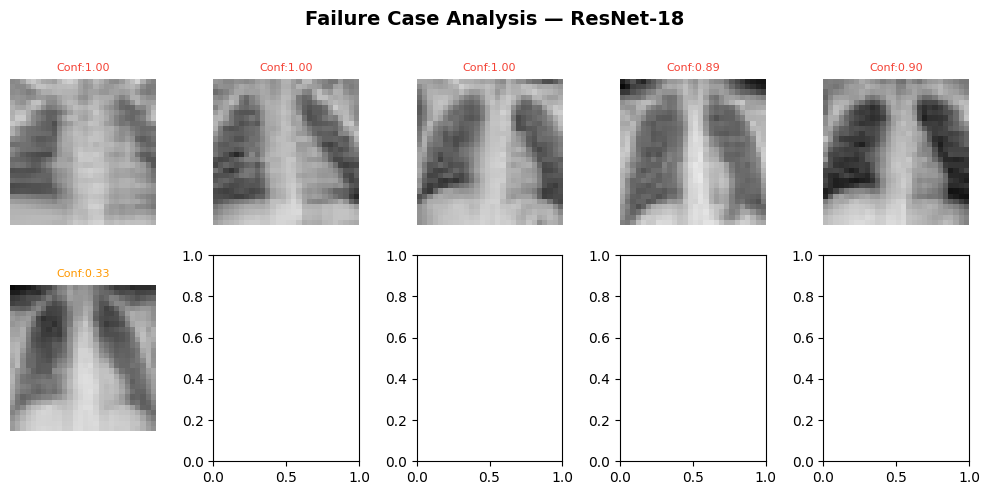


Top-5 most confident False Negatives (missed pneumonia):
  [1] image_idx=148  confidence_normal=0.670


In [27]:
fp_idx = np.where((all_preds == 1) & (all_labels == 0))[0]
fn_idx = np.where((all_preds == 0) & (all_labels == 1))[0]

print(f'False Positives (Normal → Pneumonia):  {len(fp_idx):3d}  (over-diagnosis)')
print(f'False Negatives (Pneumonia → Normal):  {len(fn_idx):3d}  ← clinically dangerous')
print(f'Total errors: {len(fp_idx)+len(fn_idx)} / {len(all_labels)} '
      f'({(len(fp_idx)+len(fn_idx))/len(all_labels)*100:.1f}%)')

N_SHOW = 5
n_fp   = min(len(fp_idx), N_SHOW)
n_fn   = min(len(fn_idx), N_SHOW)
ncols  = max(n_fp, n_fn, 1)

fig, axes = plt.subplots(2, ncols, figsize=(ncols*2, 5))
if axes.ndim == 1: axes = axes[np.newaxis, :]

for col in range(n_fp):
    idx = fp_idx[col]
    axes[0,col].imshow(denorm(all_images[idx]).squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[0,col].set_title(f'Conf:{all_probs[idx]:.2f}', fontsize=8, color='#F44336')
    axes[0,col].axis('off')
if n_fp:
    axes[0,0].set_ylabel(f'FP Normal→Pneumonia\n(n={len(fp_idx)})',
                         fontsize=9, color='#F44336', fontweight='bold')

for col in range(n_fn):
    idx = fn_idx[col]
    axes[1,col].imshow(denorm(all_images[idx]).squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[1,col].set_title(f'Conf:{all_probs[idx]:.2f}', fontsize=8, color='#FF9800')
    axes[1,col].axis('off')
if n_fn:
    axes[1,0].set_ylabel(f'FN Pneumonia→Normal\n(n={len(fn_idx)}) ← DANGEROUS',
                         fontsize=9, color='#FF9800', fontweight='bold')

for r in range(2):
    for c in range(max(n_fp, n_fn), ncols):
        axes[r,c].axis('off')

plt.suptitle(f'Failure Case Analysis — {model_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/failure_cases.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Hardest failures (most confident wrong predictions) ────────────────────
print('\nTop-5 most confident False Negatives (missed pneumonia):')
fn_sorted = fn_idx[np.argsort(all_probs[fn_idx])]  # lowest prob = most confident wrong
for i, idx in enumerate(fn_sorted[:5]):
    print(f'  [{i+1}] image_idx={idx}  confidence_normal={1-all_probs[idx]:.3f}')

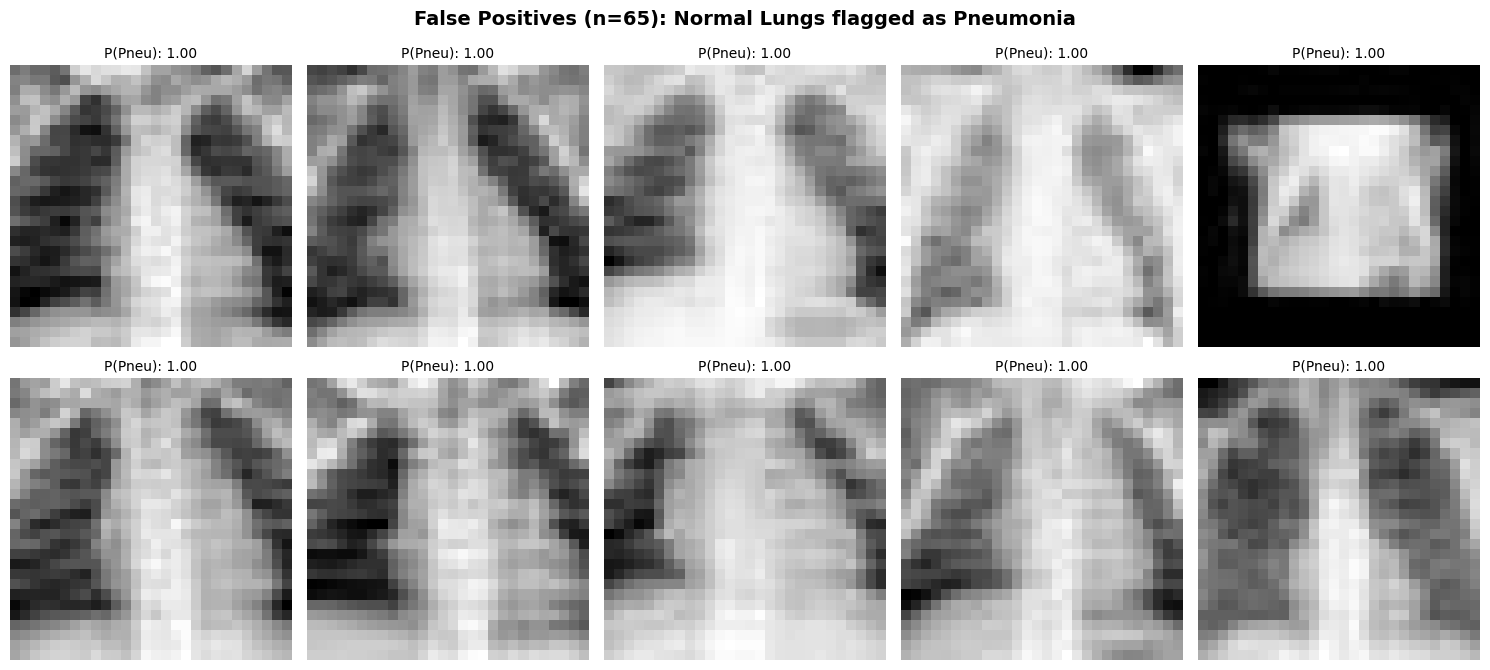

In [41]:
fp_idx = np.where((all_preds == 1) & (all_labels == 0))[0]
# Sort by highest probability (most confident errors first)
fp_sorted = fp_idx[np.argsort(all_probs[fp_idx])][::-1]

n_fp = len(fp_idx)
if n_fp > 0:
    N_TOTAL = min(n_fp, 10) # Show up to 10 images
    N_COLS = 5
    N_ROWS = (N_TOTAL + N_COLS - 1) // N_COLS # Calculates rows needed (1 or 2)
    
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 3, N_ROWS * 3.5), squeeze=False)
    
    for i in range(N_TOTAL):
        r, c = i // N_COLS, i % N_COLS # Determine row and column index
        idx = fp_sorted[i]
        
        axes[r, c].imshow(denorm(all_images[idx]).squeeze(), cmap='gray')
        axes[r, c].set_title(f'P(Pneu): {all_probs[idx]:.2f}', fontsize=10)
        axes[r, c].axis('off')
    
    # Hide any empty subplots if n_fp < 10
    for i in range(N_TOTAL, N_ROWS * N_COLS):
        axes[i // N_COLS, i % N_COLS].axis('off')
        
    plt.suptitle(f'False Positives (n={n_fp}): Normal Lungs flagged as Pneumonia', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/failure_cases_FP.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No False Positives found!")

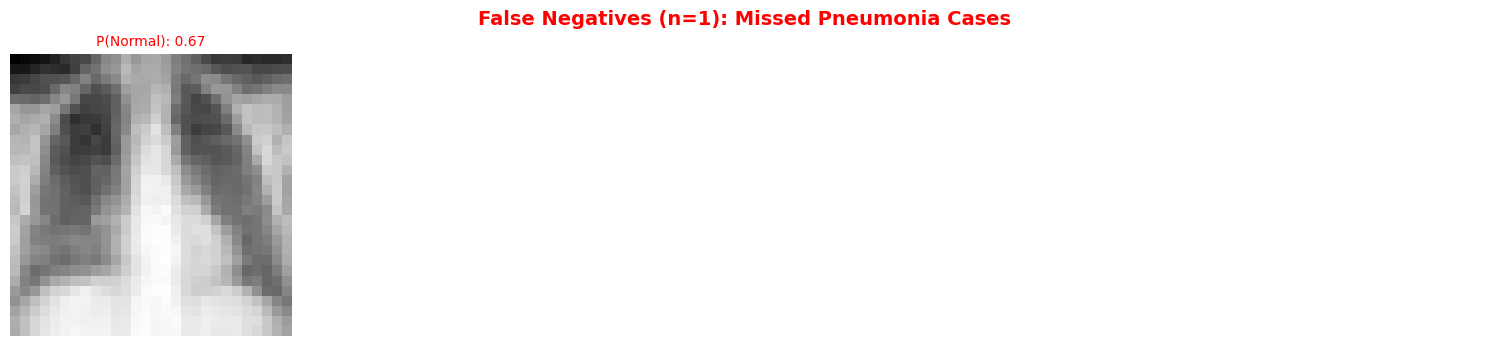

In [42]:
fn_idx = np.where((all_preds == 0) & (all_labels == 1))[0]
# Sort by lowest probability (most confident it was "Normal")
fn_sorted = fn_idx[np.argsort(all_probs[fn_idx])]

n_fn = len(fn_idx)
if n_fn > 0:
    N_TOTAL = min(n_fn, 10) # Show up to 10 images
    N_COLS = 5
    N_ROWS = (N_TOTAL + N_COLS - 1) // N_COLS 
    
    fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 3, N_ROWS * 3.5), squeeze=False)
    
    for i in range(N_TOTAL):
        r, c = i // N_COLS, i % N_COLS
        idx = fn_sorted[i]
        
        axes[r, c].imshow(denorm(all_images[idx]).squeeze(), cmap='gray')
        # Displaying confidence in being Normal (1 - prob of Pneumonia)
        axes[r, c].set_title(f'P(Normal): {1-all_probs[idx]:.2f}', fontsize=10, color='red')
        axes[r, c].axis('off')
    
    # Clean up empty subplots
    for i in range(N_TOTAL, N_ROWS * N_COLS):
        axes[i // N_COLS, i % N_COLS].axis('off')
        
    plt.suptitle(f'False Negatives (n={n_fn}): Missed Pneumonia Cases', 
                 fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/failure_cases-FN.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No False Negatives found!")

## 6. Sample Predictions Grid

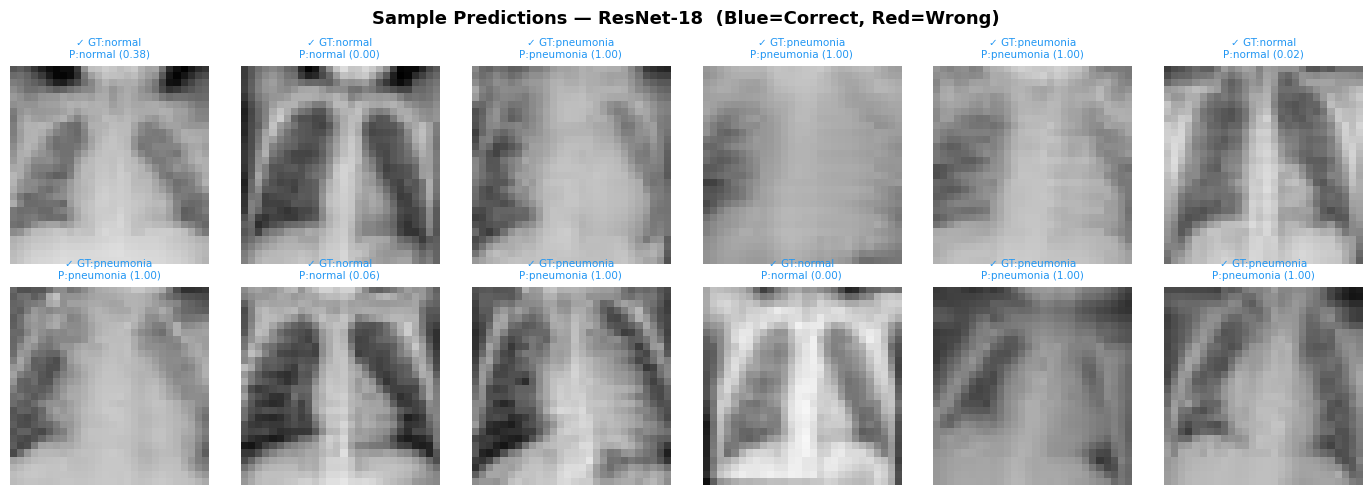

In [28]:
np.random.seed(42)
indices = np.random.choice(len(all_labels), size=12, replace=False)
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
axes = axes.flatten()

for i, idx in enumerate(indices):
    correct = all_preds[idx] == all_labels[idx]
    color   = '#2196F3' if correct else '#F44336'
    border  = '✓' if correct else '✗'
    axes[i].imshow(denorm(all_images[idx]).squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[i].set_title(
        f'{border} GT:{CLASS_NAMES[all_labels[idx]]}\n'
        f'P:{CLASS_NAMES[all_preds[idx]]} ({all_probs[idx]:.2f})',
        fontsize=7.5, color=color)
    axes[i].axis('off')

plt.suptitle(f'Sample Predictions — {model_name}  (Blue=Correct, Red=Wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Comparison of Classifiers

Run this section **after training and evaluating all models**.
It loads `test_metrics.json` from each model's output folder.

In [29]:
ALL_MODELS = ['efficientnet', 'resnet', 'custom_cnn', 'vit']
METRICS    = ['accuracy', 'precision', 'recall', 'f1', 'auc']
COLORS     = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

all_results = {}
for m in ALL_MODELS:
    path = f'outputs/{m}/test_metrics.json'
    if os.path.exists(path):
        with open(path) as f:
            all_results[m] = json.load(f)
        print(f'✓ Loaded {m}')
    else:
        print(f'✗ {m} — not trained yet (outputs/{m}/test_metrics.json not found)')

if not all_results:
    print('\nNo models evaluated yet. Run sections 1–6 for each model first.')

✓ Loaded efficientnet
✓ Loaded resnet
✓ Loaded custom_cnn
✓ Loaded vit



  MODEL COMPARISON — TEST SET
Metric                  efficientnet                resnet            custom_cnn                   vit
------------------------------------------------------------------------------------------------------
Accuracy                    0.8782                0.8942 ★              0.8894                0.8734  
Precision                   0.8384                0.8568                0.8623 ★              0.8403  
Recall                      0.9974 ★              0.9974 ★              0.9795                0.9846  
F1                          0.9110                0.9218 ★              0.9172                0.9067  
Auc                         0.9440                0.9756 ★              0.9614                0.9725  
------------------------------------------------------------------------------------------------------
★ = best for this metric


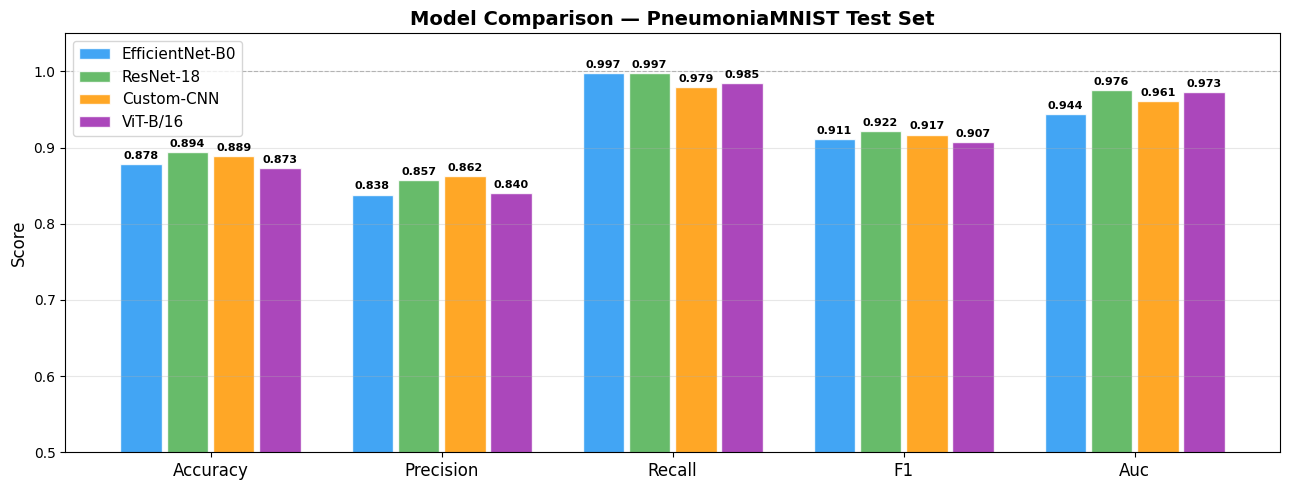

✓ Saved: outputs/model_comparison.png
✓ Saved: outputs/all_metrics.json


In [30]:
if all_results:
    models_avail = list(all_results.keys())
    colors_avail = COLORS[:len(models_avail)]

    # ── Comparison Table ───────────────────────────────────────────────────
    header  = f'{"Metric":<14}' + ''.join(f'{m:>22}' for m in models_avail)
    divider = '-' * len(header)
    print(f'\n{"="*len(header)}')
    print('  MODEL COMPARISON — TEST SET')
    print(f'{"="*len(header)}')
    print(header); print(divider)

    for metric in METRICS:
        row      = f'{metric.capitalize():<14}'
        vals     = [all_results[m].get(metric, 0) for m in models_avail]
        best_val = max(vals)
        for m, v in zip(models_avail, vals):
            star = ' ★' if abs(v - best_val) < 1e-6 else '  '
            row += f'{v:>20.4f}{star}'
        print(row)
    print(divider)
    print('★ = best for this metric')

    # ── Bar Chart ─────────────────────────────────────────────────────────
    x     = np.arange(len(METRICS))
    width = 0.8 / len(models_avail)
    fig, ax = plt.subplots(figsize=(13, 5))

    for i, (m, color) in enumerate(zip(models_avail, colors_avail)):
        vals  = [all_results[m].get(met, 0) for met in METRICS]
        label = all_results[m].get('model_name', m)
        bars  = ax.bar(x + i*width - (len(models_avail)-1)*width/2,
                       vals, width*0.9, label=label, color=color, alpha=0.85,
                       edgecolor='white')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                    f'{v:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels([m.capitalize() for m in METRICS], fontsize=12)
    ax.set_ylim(0.5, 1.05)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Model Comparison — PneumoniaMNIST Test Set',
                 fontsize=14, fontweight='bold')
    ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
    ax.axhline(1.0, color='gray', linestyle='--', lw=0.8, alpha=0.5)

    plt.tight_layout()
    plt.savefig('outputs/model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    with open('outputs/all_metrics.json', 'w') as f:
        json.dump(all_results, f, indent=2)
    print('✓ Saved: outputs/model_comparison.png')
    print('✓ Saved: outputs/all_metrics.json')

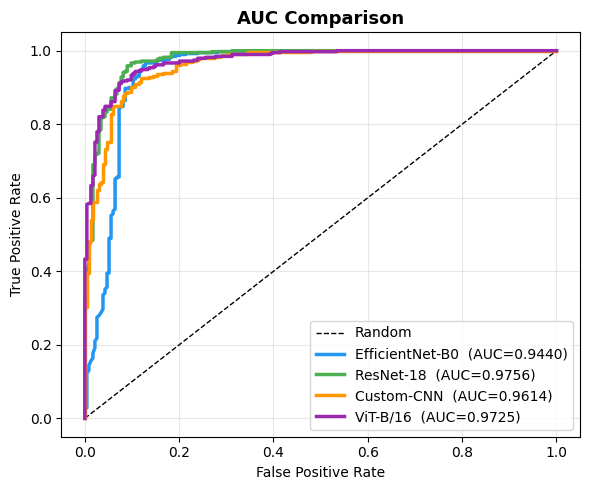

In [31]:
# ── ROC overlay comparison ──────────────────────────────────────────────────
if all_results:
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot([0,1],[0,1], 'k--', lw=1, label='Random')

    # Note: we need to re-run inference for each model to get fpr/tpr arrays
    # For simplicity, we display AUC values as a legend-only comparison
    for m, color in zip(models_avail, colors_avail):
        fpr = all_results[m]['fpr']
        tpr = all_results[m]['tpr']
        auc = all_results[m]['auc']
        name = all_results[m].get('model_name', m)
        ax.plot(fpr,tpr, color=color, lw=2.5, label=f'{name}  (AUC={auc:.4f})')

    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title('AUC Comparison', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10, loc='lower right'); ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/auc_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 8. Final Summary

In [ ]:
print('=== EVALUATION COMPLETE ===')
print(f'Current model evaluated: {model_name}')
print(f'  Accuracy:  {metrics["accuracy"]:.4f}')
print(f'  Precision: {metrics["precision"]:.4f}')
print(f'  Recall:    {metrics["recall"]:.4f}')
print(f'  F1:        {metrics["f1"]:.4f}')
print(f'  AUC:       {metrics["auc"]:.4f}')
print(f'\nFalse Positives: {len(fp_idx)} | False Negatives: {len(fn_idx)}')
print(f'\nAll plots saved in: {OUTPUT_DIR}/')
print('\n See task1_classification_report.md for written analysis')